V854 Cen run output folder: C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V854_Cen\run_20260731_125529
Resolved V854 Cen coordinate: RA=218.705844, Dec=-39.555334
Loaded 4525 cached plate results, 1 cached APASS field queries
Found 4525 V854 Cen plates in C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V854_Cen\cutouts


Done. 4525 plates in cache (135 with no usable reference stars).
Saved v854_photometry_results.csv (4525 plates)
Saved v854_reference_photometry.csv (206821 reference measurements)
Saved v854_lightcurve.csv (577 light curve points)

Fetching DASCH reference light curve...
Opened DASCH session at disk location `V854_Cen`
- Query target: `V854 Centauri`
- Refcat: 1917 sources from `apass`
- Exposures: 6100 relevant exposures
DASCH light curve: 2634 points


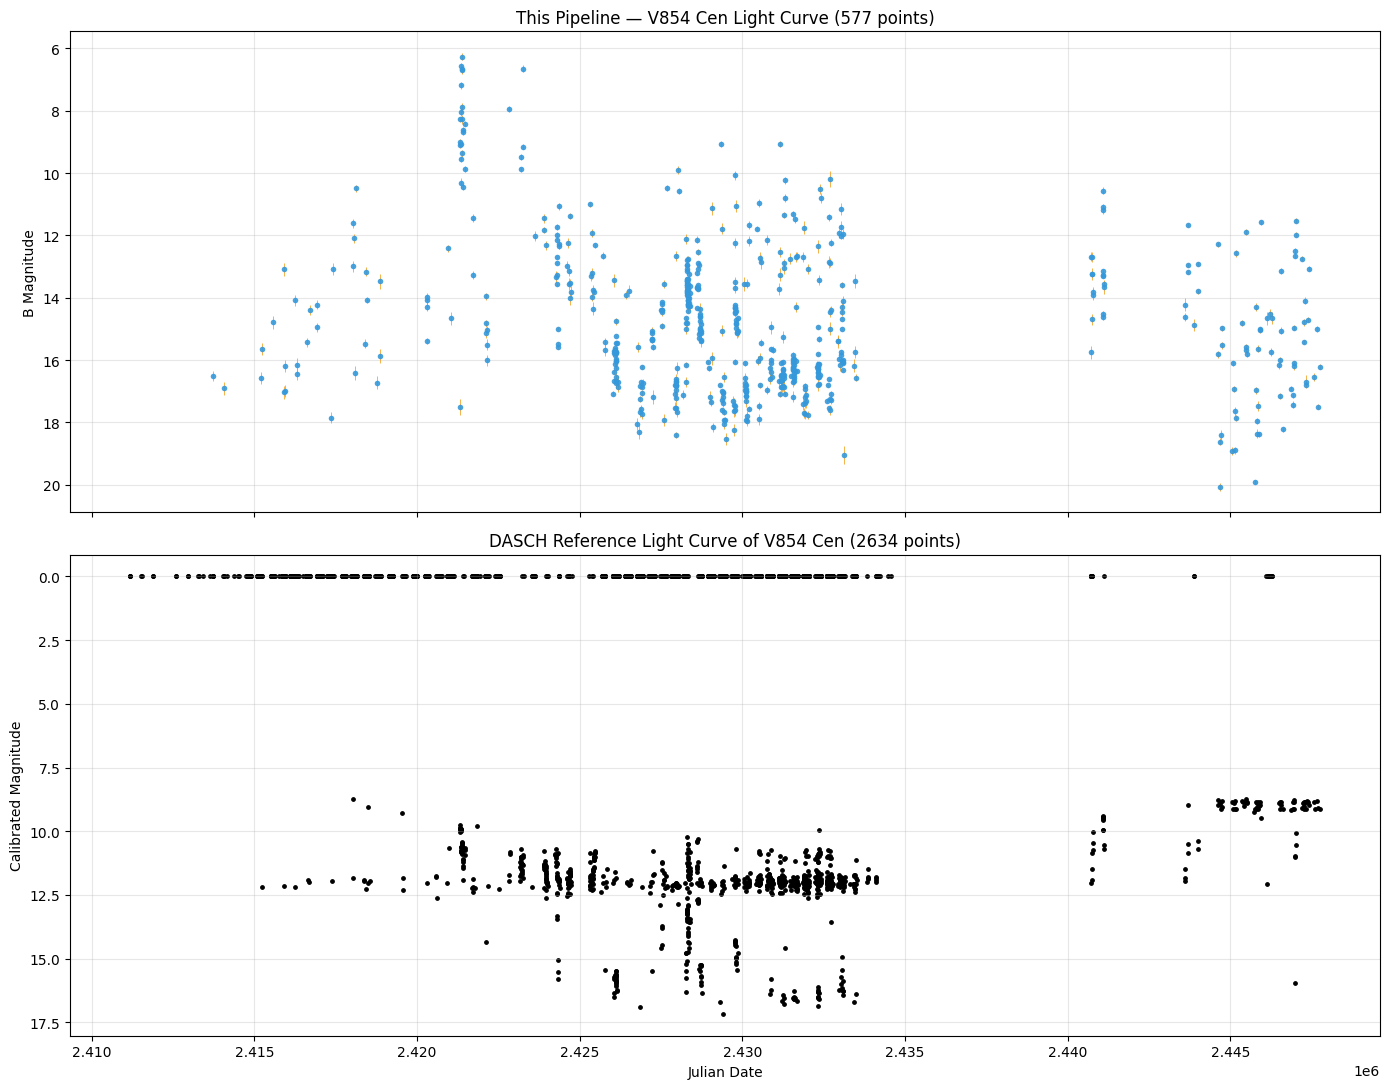

In [2]:
# NOTE : V854_Cen.ipynb - Cell 1

from pathlib import Path
from datetime import datetime
import pickle
import time
import traceback
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy.io import fits as astrofits
from astropy.wcs import WCS
from astropy.coordinates import SkyCoord
from astropy.time import Time
import astropy.units as u
from astropy.stats import SigmaClip
from photutils.aperture import (CircularAperture, CircularAnnulus,
                                 ApertureStats, aperture_photometry)
from photutils.centroids import centroid_sources, centroid_com
from photutils.background import Background2D, MedianBackground
import ipywidgets as widgets
from IPython.display import display
import urllib.request
import urllib.parse

# PATHS
V854_DIR = Path(r"C:\Users\dapur\Downloads\Other\Research\rcb_Star_Dust_Survey\test_CNN\data\V854_Cen")
V854_CUTOUTS_DIR = V854_DIR / 'cutouts'

V854_RUN_TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
V854_OUTPUT_DIR = V854_DIR / f'run_{V854_RUN_TIMESTAMP}'
V854_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

V854_CACHE_DIR = V854_DIR / 'algorithm_cache'
V854_CACHE_DIR.mkdir(parents=True, exist_ok=True)

V854_RESULTS_PATH = V854_OUTPUT_DIR / 'v854_photometry_results.csv'
V854_LIGHTCURVE_PATH = V854_OUTPUT_DIR / 'v854_lightcurve.csv'
V854_REF_PHOTOMETRY_PATH = V854_OUTPUT_DIR / 'v854_reference_photometry.csv'

print(f"V854 Cen run output folder: {V854_OUTPUT_DIR}")

# PHOTOMETRY PARAMETERS (same values validated on the synthetic benchmark)
DEFAULT_APERTURE = 6
ANNULUS_INNER = 15
ANNULUS_OUTER = 20
CENTROID_BOX = 21
CENTROID_MAX_DRIFT = 5
SIGNIF_THRESHOLD = 5.0
SATURATION_FRACTION = 0.99
SATURATION_MIN_PIXELS = 5
ISOLATION_MIN_SEPARATION = ANNULUS_OUTER + 2
MIN_REF_STARS = 10
OUTLIER_SIGMA = 3.0
MIN_ABS_SLOPE_FOR_INVERSION = 0.3
REF_STARS_MAX_PER_PLATE = 150

V854_VERSION = 2  # bumped: added per-star plate detail (plate_stars) and
                  # explicit rejection_reason tracking for the Cell 2 inspector
MIN_APASS_STARS_QUERY = 10

# TARGET COORDINATES — resolved automatically, NOT hardcoded
# Rather depend on hardcoded coordinates for future runs, this resolves the coordinate 
# live via astropy's name resolver (queries SIMBAD/Sesame under the hood).
# If you already know the exact value, or don't have internet access when running this, set
# V854_MANUAL_COORD below and it will be used instead.

V854_MANUAL_COORD = None  # e.g. SkyCoord(ra=XXX.XXXXX*u.deg, dec=-YY.YYYYY*u.deg)

if V854_MANUAL_COORD is not None:
    V854_TARGET_COORD = V854_MANUAL_COORD
    print(f"Using manually-specified target coordinate: "
          f"RA={V854_TARGET_COORD.ra.deg:.6f}, Dec={V854_TARGET_COORD.dec.deg:.6f}")
else:
    try:
        V854_TARGET_COORD = SkyCoord.from_name("V854 Centauri")
        print(f"Resolved V854 Cen coordinate: "
              f"RA={V854_TARGET_COORD.ra.deg:.6f}, Dec={V854_TARGET_COORD.dec.deg:.6f}")
    except Exception as e:
        raise RuntimeError(
            f"Could not resolve V854 Cen coordinates automatically ({e}). "
            f"Set V854_MANUAL_COORD above to a known SkyCoord and rerun."
        )

# CACHE
def v854_load_cache(name, default=None):
    path = V854_CACHE_DIR / f"{name}.pkl"
    if path.exists():
        try:
            with open(path, 'rb') as f:
                return pickle.load(f)
        except Exception:
            pass
    return default if default is not None else {}

def v854_save_cache(name, data):
    with open(V854_CACHE_DIR / f"{name}.pkl", 'wb') as f:
        pickle.dump(data, f)

v854_plate_db = v854_load_cache('plate_db', {})
apass_cache = v854_load_cache('apass_cache', {})
print(f"Loaded {len(v854_plate_db)} cached plate results, {len(apass_cache)} cached APASS field queries")

v854_cutouts = sorted(V854_CUTOUTS_DIR.glob("*.fits"))
print(f"Found {len(v854_cutouts)} V854 Cen plates in {V854_CUTOUTS_DIR}")

# CORE PHOTOMETRY & CALIBRATION FUNCTIONS
def subtract_background_2d(data, box_size=50):
    try:
        bkg = Background2D(data, (box_size, box_size), filter_size=(3, 3),
                            bkg_estimator=MedianBackground())
        return data - bkg.background, bkg.background_rms
    except Exception:
        med = np.nanmedian(data)
        return data - med, np.full_like(data, np.nanstd(data))

def refine_centroids(data, x, y, box_size=CENTROID_BOX, max_drift=CENTROID_MAX_DRIFT):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)
    if len(x) == 0:
        return x, y
    try:
        x_ref, y_ref = centroid_sources(data, x, y, box_size=box_size,
                                         centroid_func=centroid_com)
        good = np.isfinite(x_ref) & np.isfinite(y_ref)
        drift = np.hypot(x_ref - x, y_ref - y)
        good &= drift < max_drift
        x_ref[~good] = x[~good]
        y_ref[~good] = y[~good]
        return x_ref, y_ref
    except Exception:
        return x, y

def filter_isolated_stars(x, y, min_separation=ISOLATION_MIN_SEPARATION):
    n = len(x)
    if n < 2:
        return np.ones(n, dtype=bool)
    isolated = np.ones(n, dtype=bool)
    for i in range(n):
        d = np.hypot(x - x[i], y - y[i])
        d[i] = np.inf
        if np.any(d < min_separation):
            isolated[i] = False
    return isolated

def measure_aperture_photometry(data, x, y, radius=DEFAULT_APERTURE,
                                 annulus_inner=ANNULUS_INNER, annulus_outer=ANNULUS_OUTER):
    n = len(x)
    if n == 0:
        return np.array([]), np.array([]), np.array([])
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    annulus = CircularAnnulus(positions, r_in=annulus_inner, r_out=annulus_outer)
    ann_stats = ApertureStats(data, annulus, sigma_clip=SigmaClip(sigma=3.0))
    bkg_median = np.nan_to_num(ann_stats.median, nan=0.0)
    bkg_std = np.nan_to_num(ann_stats.std, nan=0.0)
    phot = aperture_photometry(data, aperture)
    flux = phot['aperture_sum'].value - bkg_median * (np.pi * radius**2)
    return flux, bkg_median, bkg_std

def detect_saturation(data, x, y, radius=DEFAULT_APERTURE,
                       sat_fraction=SATURATION_FRACTION, min_pixels=SATURATION_MIN_PIXELS):
    n = len(x)
    is_sat = np.zeros(n, dtype=bool)
    data_max = np.nanmax(data)
    if data_max <= 0:
        return is_sat
    positions = list(zip(x, y))
    aperture = CircularAperture(positions, r=radius)
    aperture_masks = aperture.to_mask(method='center')
    for i in range(n):
        mask = aperture_masks[i]
        cut = mask.multiply(data)
        if cut is None:
            continue
        star_pixels = cut[mask.data > 0]
        if len(star_pixels) == 0:
            continue
        near_max = np.sum(star_pixels >= sat_fraction * data_max)
        is_sat[i] = near_max >= min_pixels
    return is_sat

def calibrate_photometry(inst_mags, apass_b, outlier_sigma=OUTLIER_SIGMA, min_stars=MIN_REF_STARS):
    mask = np.isfinite(inst_mags) & np.isfinite(apass_b)
    if mask.sum() < min_stars:
        return None
    x = apass_b[mask]
    y = inst_mags[mask]
    for _ in range(3):
        try:
            coeffs = np.polyfit(x, y, 1)
            residuals = y - (coeffs[0] * x + coeffs[1])
            rms = np.sqrt(np.mean(residuals**2))
            good = np.abs(residuals) < outlier_sigma * rms
            if good.sum() < min_stars:
                break
            x, y = x[good], y[good]
        except Exception:
            return None
    if len(x) < min_stars:
        return None
    coeffs = np.polyfit(x, y, 1)
    residuals = y - (coeffs[0] * x + coeffs[1])
    rms = np.sqrt(np.mean(residuals**2))
    return {'slope': coeffs[0], 'intercept': coeffs[1], 'rms': rms, 'n_used': len(x)}

# LIVE APASS QUERY (real plates have no static catalog; cached by field center)
def query_apass(ra_c, dec_c, radius_arcsec, max_rows=3000):
    params = {
        '-source': 'II/336/apass9',
        '-c': f"{ra_c} {dec_c}",
        '-c.rs': radius_arcsec,
        '-out': 'RAJ2000,DEJ2000,Bmag,e_Bmag',
        '-out.max': max_rows,
    }
    url = "https://vizier.cds.unistra.fr/viz-bin/asu-tsv?" + urllib.parse.urlencode(params)
    for attempt in range(3):
        try:
            req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
            with urllib.request.urlopen(req, timeout=30) as response:
                return response.read().decode('utf-8')
        except Exception:
            time.sleep(2 ** attempt)
    return None

def parse_apass_tsv(text):
    rows = []
    for line in text.split('\n'):
        line = line.strip()
        if not line or line.startswith('#') or line.startswith('-'):
            continue
        parts = line.split('\t')
        if len(parts) < 4:
            continue
        try:
            ra, dec, bmag, e_bmag = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
            rows.append((ra, dec, bmag, e_bmag))
        except (ValueError, IndexError):
            continue
    if rows and not (0 < rows[0][2] < 25):
        rows = rows[1:]
    return rows

def get_field_catalog(ra_c, dec_c, radius_arcsec):
    key = (round(ra_c, 3), round(dec_c, 3))
    if key in apass_cache:
        return apass_cache[key]
    raw = query_apass(ra_c, dec_c, radius_arcsec)
    rows = []
    if raw:
        rows = parse_apass_tsv(raw)
        rows = [r for r in rows if 0 < r[2] < 20 and r[3] < 0.5]
    apass_cache[key] = rows
    v854_save_cache('apass_cache', apass_cache)
    return rows

# PER-PLATE PROCESSING
def get_plate_jd(header):
    if 'JD-OBS' in header:
        return float(header['JD-OBS'])
    if 'MJD-OBS' in header:
        return float(header['MJD-OBS']) + 2400000.5
    for key in ('DATE-OBS', 'DATE'):
        if key in header:
            try:
                return Time(header[key]).jd
            except Exception:
                continue
    return np.nan

def process_v854_plate(fits_path):
    try:
        data = astrofits.getdata(fits_path).astype(float)
        header = astrofits.getheader(fits_path)
        wcs = WCS(header)
        jd = get_plate_jd(header)
        data_sub, bkg_rms = subtract_background_2d(data)

        h, w = data.shape
        ra_c, dec_c = wcs.all_pix2world(w / 2, h / 2, 0)
        corners_x = [0, w - 1, 0, w - 1]
        corners_y = [0, 0, h - 1, h - 1]
        corner_ra, corner_dec = wcs.all_pix2world(corners_x, corners_y, 0)
        center = SkyCoord(float(ra_c) * u.deg, float(dec_c) * u.deg)
        corners_sky = SkyCoord(corner_ra * u.deg, corner_dec * u.deg)
        field_radius_arcsec = center.separation(corners_sky).max().arcsec * 1.05

        apass_stars = get_field_catalog(float(ra_c), float(dec_c), field_radius_arcsec)
        if len(apass_stars) < MIN_APASS_STARS_QUERY:
            return _empty_v854_result(fits_path, jd, 'Too few APASS stars in field')

        ra = np.array([s[0] for s in apass_stars])
        dec = np.array([s[1] for s in apass_stars])
        apass_b = np.array([s[2] for s in apass_stars])

        x, y = wcs.all_world2pix(ra, dec, 0)
        margin = 20
        in_frame = (x > margin) & (x < w - margin) & (y > margin) & (y < h - margin)
        x, y, apass_b = x[in_frame], y[in_frame], apass_b[in_frame]
        star_ids = np.array([f'APASS_{i:05d}' for i in range(len(x))])

        if len(x) > REF_STARS_MAX_PER_PLATE:
            keep = np.random.choice(len(x), size=REF_STARS_MAX_PER_PLATE, replace=False)
            x, y, apass_b, star_ids = x[keep], y[keep], apass_b[keep], star_ids[keep]

        if len(x) == 0:
            return _empty_v854_result(fits_path, jd, 'No APASS stars in frame')

        x_ref, y_ref = refine_centroids(data_sub, x, y)
        isolated = filter_isolated_stars(x_ref, y_ref)
        flux, bkg_med, bkg_std = measure_aperture_photometry(data_sub, x_ref, y_ref)

        area = np.pi * DEFAULT_APERTURE**2
        with np.errstate(divide='ignore', invalid='ignore'):
            snr = np.where(bkg_std > 0, flux / (bkg_std * np.sqrt(area)), 0)

        is_sat = detect_saturation(data, x_ref, y_ref)
        with np.errstate(divide='ignore', invalid='ignore'):
            inst_mag = np.where(flux > 0, -2.5 * np.log10(np.maximum(flux, 1e-10)), np.nan)

        good_for_fit = (snr >= SIGNIF_THRESHOLD) & np.isfinite(inst_mag) & ~is_sat & isolated

        # Per-star detail for every candidate star on this plate — used by
        # the Cell 2 inspector to show exactly what happened to each star.
        plate_stars = []
        for i in range(len(x_ref)):
            plate_stars.append({
                'x': float(x_ref[i]), 'y': float(y_ref[i]),
                'apass_b_mag': float(apass_b[i]),
                'instrumental_mag': float(inst_mag[i]) if np.isfinite(inst_mag[i]) else None,
                'snr': float(snr[i]),
                'isolated': bool(isolated[i]),
                'is_saturated': bool(is_sat[i]),
                'used_in_fit': bool(good_for_fit[i]),
            })

        calibration = calibrate_photometry(inst_mag[good_for_fit], apass_b[good_for_fit])
        n_ref_used = calibration['n_used'] if calibration else int(good_for_fit.sum())

        ref_rows = []
        for i in range(len(x_ref)):
            if np.isfinite(inst_mag[i]) and snr[i] >= SIGNIF_THRESHOLD and isolated[i]:
                ref_rows.append({
                    'filename': fits_path.name,
                    'star_id': star_ids[i],
                    'apass_b_mag': apass_b[i],
                    'instrumental_mag': inst_mag[i]
                })

        tx, ty = wcs.all_world2pix(V854_TARGET_COORD.ra.deg, V854_TARGET_COORD.dec.deg, 0)
        target_detected = False
        target_mag = np.nan
        target_mag_error = np.nan
        target_in_frame = margin < tx < w - margin and margin < ty < h - margin

        if target_in_frame:
            tx_ref, ty_ref = refine_centroids(data_sub, np.array([tx]), np.array([ty]))
            t_flux, t_bkg_med, t_bkg_std = measure_aperture_photometry(data_sub, tx_ref, ty_ref)
            t_area = np.pi * DEFAULT_APERTURE**2
            t_snr = t_flux[0] / (t_bkg_std[0] * np.sqrt(t_area)) if t_bkg_std[0] > 0 else 0

            if (t_snr >= SIGNIF_THRESHOLD and t_flux[0] > 0 and calibration is not None
                    and abs(calibration['slope']) >= MIN_ABS_SLOPE_FOR_INVERSION):
                t_inst_mag = -2.5 * np.log10(t_flux[0])
                target_mag = (t_inst_mag - calibration['intercept']) / calibration['slope']
                # Standard error of the calibration (rms / sqrt(n)), not the
                # raw per-star scatter — the fit is much better constrained
                # than any single reference star's residual suggests.
                calibration_uncertainty = calibration['rms'] / np.sqrt(max(calibration['n_used'], 1))
                target_mag_error = np.sqrt((1.0857 / max(t_snr, 1e-6))**2 + calibration_uncertainty**2)
                target_detected = True
                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
            else:
                tx_out, ty_out = float(tx_ref[0]), float(ty_ref[0])
        else:
            tx_out, ty_out = np.nan, np.nan

        quality_ok = (
            calibration is not None and
            n_ref_used >= MIN_REF_STARS and
            target_detected
        )

        rejection_reason = None
        if calibration is None:
            rejection_reason = 'Calibration failed (insufficient good reference stars)'
        elif n_ref_used < MIN_REF_STARS:
            rejection_reason = f'Too few reference stars in fit ({n_ref_used} < {MIN_REF_STARS})'
        elif not target_in_frame:
            rejection_reason = 'Target outside frame'
        elif not target_detected:
            rejection_reason = 'Target not detected (low SNR or unstable calibration slope)'

        result_row = {
            'filename': fits_path.name,
            'jd': jd,
            'target_detected': target_detected,
            'target_mag': target_mag,
            'target_mag_error': target_mag_error,
            'target_x': tx_out,
            'target_y': ty_out,
            'num_reference_stars': n_ref_used,
            'zeropoint': calibration['intercept'] if calibration else np.nan,
            'rms_scatter': calibration['rms'] if calibration else np.nan,
            'slope': calibration['slope'] if calibration else np.nan,
            'quality_ok': quality_ok,
            'rejection_reason': rejection_reason,
        }
        return {'result_row': result_row, 'ref_rows': ref_rows, 'plate_stars': plate_stars, 'calibration': calibration}

    except Exception as e:
        print(f"Error processing {fits_path.name}: {e}")
        return _empty_v854_result(fits_path, np.nan, str(e))

def _empty_v854_result(fits_path, jd, reason):
    return {
        'result_row': {
            'filename': fits_path.name, 'jd': jd, 'target_detected': False,
            'target_mag': np.nan, 'target_mag_error': np.nan,
            'target_x': np.nan, 'target_y': np.nan,
            'num_reference_stars': 0, 'zeropoint': np.nan,
            'rms_scatter': np.nan, 'slope': np.nan, 'quality_ok': False,
            'rejection_reason': reason,
        },
        'ref_rows': [],
        'plate_stars': [],
        'calibration': None,
    }



# RUN PIPELINE
progress_bar = widgets.IntProgress(value=0, min=0, max=len(v854_cutouts), description='Processing:')
progress_html = widgets.HTML(value="")
progress_status = widgets.Label(value="Not started")
display(widgets.VBox([progress_bar, progress_html, progress_status]))

def format_eta(seconds):
    if seconds is None or seconds != seconds or seconds < 0:
        return "calculating..."
    m, s = divmod(int(seconds), 60)
    h, m = divmod(m, 60)
    return f"{h:d}:{m:02d}:{s:02d}" if h else f"{m:d}:{s:02d}"

def render_progress(n_done, total, start_time):
    elapsed = time.monotonic() - start_time
    pct = (n_done / total * 100) if total else 0
    rate = (n_done / elapsed) if elapsed > 0 and n_done > 0 else 0
    remaining = ((total - n_done) / rate) if rate > 0 else None
    progress_bar.value = n_done
    progress_html.value = (
        f"<div style='font-family: monospace; font-size: 13px;'>"
        f"<b>{pct:5.1f}%</b> &nbsp; {n_done:,} / {total:,} plates &nbsp;|&nbsp; "
        f"{rate:.2f} plates/sec &nbsp;|&nbsp; "
        f"Elapsed {format_eta(elapsed)} &nbsp;|&nbsp; ETA {format_eta(remaining)}"
        f"</div>"
    )

def run_v854_pipeline(force_reprocess=False):
    global v854_plate_db
    total = max(len(v854_cutouts), 1)
    progress_bar.max = total
    progress_bar.value = 0
    start = time.monotonic()
    last_render = 0.0
    n_errors = 0

    for i, f in enumerate(v854_cutouts):
        cached = v854_plate_db.get(str(f))
        if not force_reprocess and cached and cached.get('_version', 0) == V854_VERSION:
            pass
        else:
            progress_status.value = f"Processing: {f.name}"
            out = process_v854_plate(f)
            if out['result_row'].get('num_reference_stars', 0) == 0 and out['calibration'] is None:
                n_errors += 1
            out['_version'] = V854_VERSION
            v854_plate_db[str(f)] = out

        now = time.monotonic()
        if now - last_render > 0.15 or (i + 1) == total:
            render_progress(i + 1, total, start)
            last_render = now

        if (i + 1) % 50 == 0:
            v854_save_cache('plate_db', v854_plate_db)

    v854_save_cache('plate_db', v854_plate_db)
    progress_status.value = f"Done. {len(v854_plate_db)} plates in cache ({n_errors} with no usable reference stars)."
    print(progress_status.value)
    return _save_v854_outputs()

def _save_v854_outputs():
    result_rows, ref_rows_all = [], []
    for f_str, out in v854_plate_db.items():
        if out is None:
            continue
        result_rows.append(out['result_row'])
        ref_rows_all.extend(out['ref_rows'])

    results_df = pd.DataFrame(result_rows).sort_values('jd').reset_index(drop=True)
    results_df.to_csv(V854_RESULTS_PATH, index=False)
    print(f"Saved {V854_RESULTS_PATH.name} ({len(results_df)} plates)")

    ref_df = pd.DataFrame(ref_rows_all)
    ref_df.to_csv(V854_REF_PHOTOMETRY_PATH, index=False)
    print(f"Saved {V854_REF_PHOTOMETRY_PATH.name} ({len(ref_df)} reference measurements)")

    lc_df = results_df[results_df['quality_ok']].copy()
    lc_df = lc_df.rename(columns={'target_mag': 'magnitude', 'target_mag_error': 'magnitude_error'})
    lc_df = lc_df[['jd', 'magnitude', 'magnitude_error']].dropna()
    lc_df.to_csv(V854_LIGHTCURVE_PATH, index=False)
    print(f"Saved {V854_LIGHTCURVE_PATH.name} ({len(lc_df)} light curve points)")

    return results_df, ref_df, lc_df

v854_results_df = pd.DataFrame()
v854_ref_df = pd.DataFrame()
v854_lc_df = pd.DataFrame()

try:
    v854_results_df, v854_ref_df, v854_lc_df = run_v854_pipeline(force_reprocess=False)
except Exception as e:
    print(f"\n❌ ERROR: run_v854_pipeline failed: {e}")
    traceback.print_exc()

# DASCH LIGHT CURVE (independent reference, for comparison)
dasch_jd, dasch_mag = None, None
try:
    from daschlab import Session

    print("\nFetching DASCH reference light curve...")
    sess = Session("V854_Cen")
    sess.select_target("V854 Centauri")
    sess.select_refcat("apass")
    lc = sess.lightcurve(0)

    dasch_jd_raw = np.asarray(lc["time"].jd)
    dasch_mag_raw = np.asarray(lc["magcal_magdep"].value)
    good = np.isfinite(dasch_jd_raw) & np.isfinite(dasch_mag_raw)
    dasch_jd, dasch_mag = dasch_jd_raw[good], dasch_mag_raw[good]
    print(f"DASCH light curve: {len(dasch_jd)} points")
except Exception as e:
    print(f"Warning: could not fetch DASCH light curve ({e})")

# COMBINED COMPARISON PLOT
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

if len(v854_lc_df) > 0:
    ax1.errorbar(v854_lc_df['jd'], v854_lc_df['magnitude'], yerr=v854_lc_df['magnitude_error'],
                 fmt='o', color='#3498db', markersize=4,
                 ecolor='#f39c12', elinewidth=0.6, capsize=1.5, capthick=0.6,
                 alpha=0.9, markeredgewidth=0)
else:
    ax1.text(0.5, 0.5, 'No quality-passing plates', ha='center', va='center', transform=ax1.transAxes)
ax1.invert_yaxis()
ax1.set_ylabel('B Magnitude')
ax1.set_title(f'This Pipeline — V854 Cen Light Curve ({len(v854_lc_df)} points)')
ax1.grid(True, alpha=0.3)

if dasch_jd is not None and len(dasch_jd) > 0:
    ax2.scatter(dasch_jd, dasch_mag, s=6, color="black")
else:
    ax2.text(0.5, 0.5, 'DASCH light curve unavailable', ha='center', va='center', transform=ax2.transAxes)
ax2.invert_yaxis()
ax2.set_xlabel('Julian Date')
ax2.set_ylabel('Calibrated Magnitude')
ax2.set_title(f'DASCH Reference Light Curve of V854 Cen'
              f'{f" ({len(dasch_jd)} points)" if dasch_jd is not None else ""}')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================================
# V854_Cen.ipynb - Cell 2: Per-Plate Inspector
# Requires Cell 1 already run in this session (uses v854_plate_db,
# v854_cutouts, V854_TARGET_COORD, and the core functions defined there).
# ============================================================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from astropy.wcs import WCS
from astropy.io import fits as astrofits
import ipywidgets as widgets
from IPython.display import display, clear_output

# Dropdown built from actual cutout files (not just cached ones), so you can
# select any plate even before/after it's been processed this session.
v854_plate_options = [(f.name, f) for f in v854_cutouts]

plate_inspect_dropdown = widgets.Dropdown(
    options=v854_plate_options,
    description="Plate:"
)
plate_inspect_toggle = widgets.ToggleButton(
    value=False,
    description="Show Plate Details",
    button_style='info',
    icon='eye'
)
plate_inspect_output = widgets.Output()

def _plate_status_summary(row):
    """Human-readable one-line status for the title bar."""
    if row is None:
        return "Not processed"
    if row.get('quality_ok'):
        return "✓ PASSED — included in light curve"
    reason = row.get('rejection_reason') or "unknown"
    return f"✗ EXCLUDED — {reason}"

def _render_plate_inspector(fits_path):
    key = str(fits_path)
    cached = v854_plate_db.get(key)

    if cached is None:
        print(f"'{Path(fits_path).name}' has not been processed yet — run the pipeline (Cell 1) first.")
        return

    row = cached.get('result_row', {})
    calibration = cached.get('calibration')
    plate_stars = cached.get('plate_stars', [])
    target_x, target_y = row.get('target_x'), row.get('target_y')

    # --- Load image for display ---
    try:
        data = astrofits.getdata(fits_path).astype(float)
    except Exception as e:
        print(f"Could not load image data: {e}")
        return

    fig, (ax_img, ax_info) = plt.subplots(1, 2, figsize=(16, 8),
                                           gridspec_kw={'width_ratios': [1.3, 1]})

    # --- Image panel ---
    vmin = np.nanpercentile(data, 5)
    vmax = np.nanpercentile(data, 99.5)
    ax_img.imshow(data, origin='lower', cmap='gray', vmin=vmin, vmax=vmax)

    # Plot every candidate star, color-coded by what happened to it:
    #   green  = used in the calibration fit
    #   orange = isolated & unsaturated, but too faint (didn't clear SNR)
    #   red    = saturated
    #   gray   = rejected for crowding (not isolated)
    legend_handles = []
    if plate_stars:
        used_x = [s['x'] for s in plate_stars if s['used_in_fit']]
        used_y = [s['y'] for s in plate_stars if s['used_in_fit']]
        sat_x = [s['x'] for s in plate_stars if s['is_saturated']]
        sat_y = [s['y'] for s in plate_stars if s['is_saturated']]
        crowded_x = [s['x'] for s in plate_stars if not s['isolated'] and not s['is_saturated']]
        crowded_y = [s['y'] for s in plate_stars if not s['isolated'] and not s['is_saturated']]
        faint_x = [s['x'] for s in plate_stars
                   if s['isolated'] and not s['is_saturated'] and not s['used_in_fit']]
        faint_y = [s['y'] for s in plate_stars
                   if s['isolated'] and not s['is_saturated'] and not s['used_in_fit']]

        if used_x:
            ax_img.scatter(used_x, used_y, s=40, facecolors='none', edgecolors='#2ecc71',
                           linewidths=1.2, label=f'Used in fit ({len(used_x)})')
        if faint_x:
            ax_img.scatter(faint_x, faint_y, s=30, facecolors='none', edgecolors='#f39c12',
                           linewidths=1.0, label=f'Too faint / low SNR ({len(faint_x)})')
        if crowded_x:
            ax_img.scatter(crowded_x, crowded_y, s=30, facecolors='none', edgecolors='#95a5a6',
                           linewidths=1.0, label=f'Crowded (rejected) ({len(crowded_x)})')
        if sat_x:
            ax_img.scatter(sat_x, sat_y, s=30, facecolors='none', edgecolors='#e74c3c',
                           linewidths=1.0, label=f'Saturated ({len(sat_x)})')

    # Highlight the target
    if target_x is not None and target_y is not None and np.isfinite(target_x) and np.isfinite(target_y):
        color = '#3498db' if row.get('target_detected') else '#e74c3c'
        ax_img.scatter([target_x], [target_y], s=180, facecolors='none', edgecolors=color,
                       linewidths=2.2, marker='o')
        ax_img.annotate('V854 Cen', (target_x, target_y), xytext=(10, 10),
                        textcoords='offset points', color=color, fontsize=10, fontweight='bold')

    ax_img.set_title(f"{Path(fits_path).name}\n{_plate_status_summary(row)}", fontsize=11)
    if plate_stars:
        ax_img.legend(loc='upper right', fontsize=8, framealpha=0.85)
    ax_img.set_xlabel('X (pixels)')
    ax_img.set_ylabel('Y (pixels)')

    # --- Info panel ---
    ax_info.axis('off')

    lines = []
    lines.append(f"FILE: {Path(fits_path).name}")
    lines.append(f"JD: {row.get('jd', float('nan')):.5f}" if row.get('jd') == row.get('jd') else "JD: unavailable")
    lines.append("")
    lines.append("— Detection & Photometry —")
    lines.append(f"Reference stars in frame: {len(plate_stars)}")
    if plate_stars:
        n_used = sum(1 for s in plate_stars if s['used_in_fit'])
        n_sat = sum(1 for s in plate_stars if s['is_saturated'])
        n_crowded = sum(1 for s in plate_stars if not s['isolated'] and not s['is_saturated'])
        n_faint = sum(1 for s in plate_stars
                      if s['isolated'] and not s['is_saturated'] and not s['used_in_fit'])
        lines.append(f"  Used in calibration fit: {n_used}")
        lines.append(f"  Too faint / low SNR: {n_faint}")
        lines.append(f"  Rejected (crowded): {n_crowded}")
        lines.append(f"  Saturated: {n_sat}")
    lines.append("")
    lines.append("— Calibration —")
    if calibration is not None:
        lines.append(f"  Slope: {calibration['slope']:.4f}")
        lines.append(f"  Intercept (zeropoint): {calibration['intercept']:.3f}")
        lines.append(f"  RMS: {calibration['rms']:.4f} mag")
        lines.append(f"  N stars used: {calibration['n_used']}")
    else:
        lines.append("  No calibration fit produced")
    lines.append("")
    lines.append("— Target (V854 Cen) —")
    lines.append(f"  Detected: {'Yes' if row.get('target_detected') else 'No'}")
    if row.get('target_detected'):
        lines.append(f"  Magnitude: {row.get('target_mag'):.3f} ± {row.get('target_mag_error'):.3f}")
    lines.append("")
    lines.append("— Classification —")
    lines.append(f"  quality_ok: {row.get('quality_ok')}")
    lines.append(f"  Status: {_plate_status_summary(row)}")

    ax_info.text(0.02, 0.98, "\n".join(lines), transform=ax_info.transAxes,
                fontsize=10.5, verticalalignment='top', family='monospace',
                bbox=dict(boxstyle='round', facecolor='#f7f7f7', edgecolor='#ccc', alpha=0.95))

    plt.tight_layout()
    plt.show()

def _on_plate_inspect_toggle(change):
    with plate_inspect_output:
        clear_output(wait=True)
        if plate_inspect_toggle.value:
            plate_inspect_toggle.description = "Hide Plate Details"
            plate_inspect_toggle.icon = 'eye-slash'
            _render_plate_inspector(plate_inspect_dropdown.value)
        else:
            plate_inspect_toggle.description = "Show Plate Details"
            plate_inspect_toggle.icon = 'eye'

def _on_plate_inspect_change(change):
    if plate_inspect_toggle.value:
        _on_plate_inspect_toggle(None)

plate_inspect_toggle.observe(_on_plate_inspect_toggle, names='value')
plate_inspect_dropdown.observe(_on_plate_inspect_change, names='value')

display(widgets.VBox([
    widgets.HTML("<b>Per-Plate Inspector</b> — star detections, photometry, and classification for a single plate"),
    widgets.HBox([plate_inspect_dropdown, plate_inspect_toggle]),
    plate_inspect_output
]))